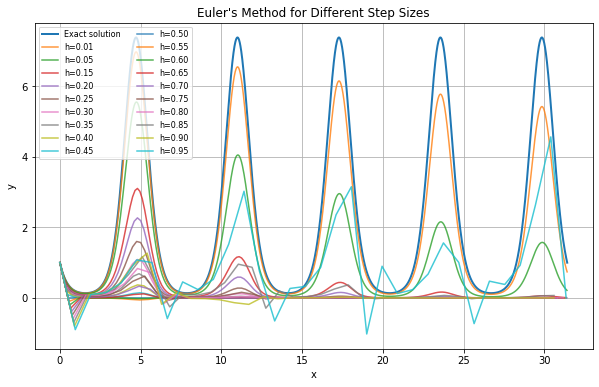

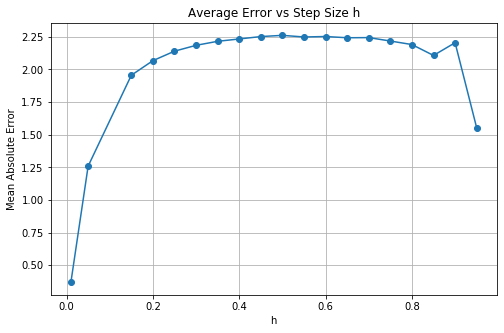

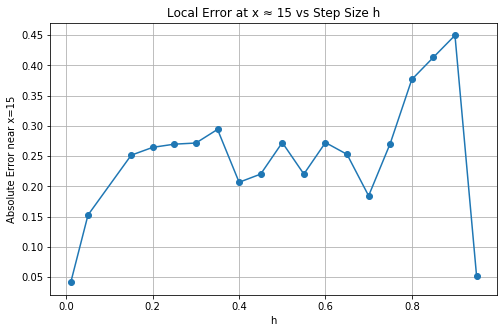

h	Average y	Average Error	Nearest x to 15	Euler y(x≈15)	Local Error
0.01	1.910827	0.368593	15.0000		0.231440		0.040935
0.05	1.018602	1.259614	15.0000		0.119869		0.152506
0.15	0.320505	1.955839	15.0000		0.020921		0.251454
0.20	0.204568	2.067651	15.0000		0.007903		0.264472
0.25	0.136335	2.140288	15.0000		0.002662		0.269713
0.30	0.091602	2.185167	15.0000		0.000753		0.271622
0.35	0.061013	2.215906	15.0500		0.000170		0.294172
0.40	0.039514	2.233876	14.8000		0.000018		0.206679
0.45	0.024970	2.252260	14.8500		0.000001		0.220242
0.50	0.015873	2.261520	15.0000		-0.000000		0.272375
0.55	0.011968	2.249053	14.8500		0.000000		0.220243
0.60	0.013873	2.252663	15.0000		-0.000000		0.272375
0.65	0.021701	2.243102	14.9500		0.000016		0.252852
0.70	0.033776	2.244302	14.7000		0.000005		0.184239
0.75	0.060223	2.218037	15.0000		0.001574		0.270801
0.80	0.068476	2.191062	15.2000		0.001268		0.376756
0.85	0.172581	2.107630	15.3000		0.038863		0.413405
0.90	0.073782	2.205192	15.3000		0.002522		0.449745
0.95	0.78985

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def y_exact(x):
    return np.exp(-2 * np.sin(x))

def euler_method(h, x_end):
    n_steps = int(np.floor(x_end / h))
    x = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)

    x[0] = 0.0
    y[0] = 1.0

    for i in range(n_steps):
        x[i + 1] = x[i] + h
        y[i + 1] = y[i] + h * f(x[i], y[i])

    return x, y

x_end = 10 * np.pi

h_values = [0.01, 0.05] + list(np.arange(0.15, 1.0, 0.05))

avg_y_values = []
avg_errors = []
local_errors = []
y_near_15_values = []

x_fine = np.linspace(0, x_end, 3000)
y_fine = y_exact(x_fine)

plt.figure(figsize=(10, 6))
plt.plot(x_fine, y_fine, label='Exact solution', linewidth=2)

for h in h_values:
    x, y = euler_method(h, x_end)

    avg_y = np.mean(y)
    avg_y_values.append(avg_y)

    exact_vals = y_exact(x)
    avg_error = np.mean(np.abs(y - exact_vals))
    avg_errors.append(avg_error)

    idx_15 = np.argmin(np.abs(x - 15))
    x_near_15 = x[idx_15]
    y_near_15 = y[idx_15]
    y_true_15 = y_exact(x_near_15)

    y_near_15_values.append((h, x_near_15, y_near_15))
    local_errors.append(abs(y_near_15 - y_true_15))

    plt.plot(x, y, label=f'h={h:.2f}', alpha=0.8)

plt.title("Euler's Method for Different Step Sizes")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.title("Average Error vs Step Size h")
plt.xlabel("h")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors, marker='o')
plt.title("Local Error at x ≈ 15 vs Step Size h")
plt.xlabel("h")
plt.ylabel("Absolute Error near x=15")
plt.grid(True)
plt.show()

print("h\tAverage y\tAverage Error\tNearest x to 15\tEuler y(x≈15)\tLocal Error")
for i, h in enumerate(h_values):
    x15 = y_near_15_values[i][1]
    y15 = y_near_15_values[i][2]
    print(f"{h:.2f}\t{avg_y_values[i]:.6f}\t{avg_errors[i]:.6f}\t{x15:.4f}\t\t{y15:.6f}\t\t{local_errors[i]:.6f}")

Euler’s method approximates the solution by following the slope of the differential equation one step at a time. For smaller step sizes, the numerical solution stays much closer to the exact solution y=e^(−2sinx), while larger step sizes accumulate more error. This is visible in the first plot, where the curves for small h track the exact solution more closely. The average error increases as h increases because Euler’s method is a first-order method, so its global error is approximately proportional to the step size. The local error near x = 15 also tends to increase with larger h, since bigger steps give a less accurate estimate of the solution at each point. Overall, smaller step sizes produce more accurate approximations but require more computation.